In [1]:
from sys import prefix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from requests.packages import target

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("D:\\IIT\\2nd Year\\Group project\\model\\database.csv",low_memory=False)
df.head(20)

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI
5,6,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,May,1,Murder or Manslaughter,...,Unknown,Male,36,White,Unknown,Acquaintance,Rifle,0,0,FBI
6,7,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,May,2,Murder or Manslaughter,...,Unknown,Male,27,Black,Unknown,Wife,Knife,0,0,FBI
7,8,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,June,1,Murder or Manslaughter,...,Unknown,Male,35,White,Unknown,Wife,Knife,0,0,FBI
8,9,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,June,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Firearm,0,0,FBI
9,10,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,June,3,Murder or Manslaughter,...,Unknown,Male,40,Unknown,Unknown,Unknown,Firearm,0,1,FBI


In [3]:
df.shape

(638454, 24)

In [4]:
unique_values = df['Victim Age'].unique()
for value in unique_values:
    print(f"{value} : {(df['Victim Age'] == value).sum()}")


14 : 3342
43 : 8629
30 : 18966
42 : 9613
99 : 9281
32 : 15812
38 : 11411
36 : 12502
20 : 23031
48 : 6365
31 : 15762
16 : 9402
33 : 14463
27 : 19465
21 : 22796
60 : 3171
40 : 11163
18 : 18469
8 : 852
25 : 22939
24 : 21830
46 : 7336
23 : 22438
22 : 23049
45 : 8157
26 : 20469
58 : 3272
17 : 14030
29 : 18037
41 : 9594
68 : 1840
13 : 1897
35 : 14314
44 : 7921
54 : 4466
37 : 11829
51 : 5270
90 : 281
50 : 6325
52 : 5203
61 : 2797
63 : 2519
19 : 21939
28 : 18199
70 : 1783
72 : 1596
74 : 1367
53 : 4788
57 : 3721
76 : 1213
79 : 1098
69 : 1663
34 : 14296
66 : 1861
55 : 4246
67 : 2013
65 : 2418
47 : 6902
1 : 5525
49 : 6149
62 : 2862
75 : 1411
56 : 3939
59 : 3184
78 : 1102
39 : 10921
15 : 5905
0 : 8444
71 : 1566
77 : 1135
2 : 3805
4 : 1659
64 : 2271
82 : 835
85 : 627
6 : 999
5 : 1194
7 : 915
9 : 834
84 : 686
10 : 854
86 : 574
11 : 911
73 : 1390
83 : 765
998 : 974
81 : 930
87 : 460
80 : 1067
3 : 2378
12 : 1239
94 : 116
93 : 134
92 : 156
89 : 313
97 : 39
88 : 408
91 : 215
95 : 82
98 : 33
96 : 37


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Record ID              638454 non-null  int64 
 1   Agency Code            638454 non-null  object
 2   Agency Name            638454 non-null  object
 3   Agency Type            638454 non-null  object
 4   City                   638454 non-null  object
 5   State                  638454 non-null  object
 6   Year                   638454 non-null  int64 
 7   Month                  638454 non-null  object
 8   Incident               638454 non-null  int64 
 9   Crime Type             638454 non-null  object
 10  Crime Solved           638454 non-null  object
 11  Victim Sex             638454 non-null  object
 12  Victim Age             638454 non-null  int64 
 13  Victim Race            638454 non-null  object
 14  Victim Ethnicity       638454 non-null  object
 15  

Dataset Preprocessing

In [6]:
df.drop(['Record ID'],axis=1, inplace=True) #Since year is not doing much thing in the prediction
df.drop(['Agency Code'],axis=1, inplace=True)
df.drop(['Agency Name'],axis=1, inplace=True)
df.drop(['Agency Type'],axis=1, inplace=True)
df.drop(['Crime Solved'],axis=1, inplace=True)
df.drop(['Record Source'],axis=1, inplace=True)
df.drop(['Year'],axis=1, inplace=True)
df.drop(['Incident'],axis=1, inplace=True)
df.drop(['Victim Count'],axis=1, inplace=True)
df.drop(['Perpetrator Count'],axis=1, inplace=True)
df.drop(['Perpetrator Race'],axis=1, inplace=True)
df.drop(['Relationship'],axis=1, inplace=True)




In [7]:
df.head(10)

,City,State,Month,Crime Type,Victim Sex,Victim Age,Victim Race,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Ethnicity,Weapon
0,Anchorage,Alaska,January,Murder or Manslaughter,Male,14,Native American/Alaska Native,Unknown,Male,15,Unknown,Blunt Object
1,Anchorage,Alaska,March,Murder or Manslaughter,Male,43,White,Unknown,Male,42,Unknown,Strangulation
2,Anchorage,Alaska,March,Murder or Manslaughter,Female,30,Native American/Alaska Native,Unknown,Unknown,0,Unknown,Unknown
3,Anchorage,Alaska,April,Murder or Manslaughter,Male,43,White,Unknown,Male,42,Unknown,Strangulation
4,Anchorage,Alaska,April,Murder or Manslaughter,Female,30,Native American/Alaska Native,Unknown,Unknown,0,Unknown,Unknown
5,Anchorage,Alaska,May,Murder or Manslaughter,Male,30,White,Unknown,Male,36,Unknown,Rifle
6,Anchorage,Alaska,May,Murder or Manslaughter,Female,42,Native American/Alaska Native,Unknown,Male,27,Unknown,Knife
7,Anchorage,Alaska,June,Murder or Manslaughter,Female,99,White,Unknown,Male,35,Unknown,Knife
8,Anchorage,Alaska,June,Murder or Manslaughter,Male,32,White,Unknown,Unknown,0,Unknown,Firearm
9,Anchorage,Alaska,June,Murder or Manslaughter,Male,38,White,Unknown,Male,40,Unknown,Firearm


In [8]:
df.drop(df[df['Victim Age']==998].index,axis=0,inplace=True)

In [9]:
(df['Victim Age']==0).sum()

8444

In [10]:
cat_features = []

for column in df.select_dtypes(include=object).columns:
        cat_features.append(column)

for cat_featurer in cat_features:
    print(cat_featurer)


City
State
Month
Crime Type
Victim Sex
Victim Race
Victim Ethnicity
Perpetrator Sex
Perpetrator Age
Perpetrator Ethnicity
Weapon


In [11]:
duplicated_rows = df.duplicated().tolist()
df[duplicated_rows].count()


City                     66756
State                    66756
Month                    66756
Crime Type               66756
Victim Sex               66756
Victim Age               66756
Victim Race              66756
Victim Ethnicity         66756
Perpetrator Sex          66756
Perpetrator Age          66756
Perpetrator Ethnicity    66756
Weapon                   66756
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(570724, 12)

In [14]:
unique_values = df['Perpetrator Age'].unique()
for value in unique_values:
    print(f"{value} : {(df['Perpetrator Age'] == value).sum()}")

15 : 5298
42 : 5821
0 : 159419
36 : 8140
27 : 13817
35 : 9593
40 : 6951
49 : 3554
39 : 6964
29 : 12296
19 : 19141
23 : 17069
33 : 9790
26 : 14409
41 : 6096
28 : 13201
61 : 1247
25 : 16981
7 : 48
17 : 13465
34 : 9227
21 : 18216
43 : 5418
38 : 7297
66 : 785
32 : 10694
37 : 7868
22 : 17730
30 : 13328
24 : 15936
65 : 923
51 : 2971
60 : 1435
45 : 4976
64 : 1037
18 : 17631
20 : 20237
44 : 4975
73 : 470
62 : 1138
69 : 616
52 : 2718
16 : 9032
90 : 58
56 : 1974
47 : 4077
57 : 1745
31 : 10765
46 : 4075
14 : 2536
55 : 2211
50 : 3420
54 : 2307
68 : 725
77 : 314
53 : 2514
67 : 781
48 : 3810
76 : 360
58 : 1646
71 : 533
63 : 1025
89 : 56
13 : 1104
75 : 372
72 : 502
93 : 17
59 : 1552
10 : 145
11 : 223
79 : 249
74 : 374
99 : 89
70 : 593
78 : 280
80 : 250
9 : 86
12 : 480
81 : 227
6 : 50
87 : 113
82 : 206
83 : 166
8 : 62
84 : 140
85 : 139
86 : 103
5 : 32
3 : 24
1 : 34
88 : 85
95 : 9
4 : 29
91 : 33
92 : 32
96 : 7
94 : 10
2 : 6
98 : 7
97 : 3
  : 1


In [15]:
df.head(10)

,City,State,Month,Crime Type,Victim Sex,Victim Age,Victim Race,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Ethnicity,Weapon
0,Anchorage,Alaska,January,Murder or Manslaughter,Male,14,Native American/Alaska Native,Unknown,Male,15,Unknown,Blunt Object
1,Anchorage,Alaska,March,Murder or Manslaughter,Male,43,White,Unknown,Male,42,Unknown,Strangulation
2,Anchorage,Alaska,March,Murder or Manslaughter,Female,30,Native American/Alaska Native,Unknown,Unknown,0,Unknown,Unknown
3,Anchorage,Alaska,April,Murder or Manslaughter,Male,43,White,Unknown,Male,42,Unknown,Strangulation
4,Anchorage,Alaska,April,Murder or Manslaughter,Female,30,Native American/Alaska Native,Unknown,Unknown,0,Unknown,Unknown
5,Anchorage,Alaska,May,Murder or Manslaughter,Male,30,White,Unknown,Male,36,Unknown,Rifle
6,Anchorage,Alaska,May,Murder or Manslaughter,Female,42,Native American/Alaska Native,Unknown,Male,27,Unknown,Knife
7,Anchorage,Alaska,June,Murder or Manslaughter,Female,99,White,Unknown,Male,35,Unknown,Knife
8,Anchorage,Alaska,June,Murder or Manslaughter,Male,32,White,Unknown,Unknown,0,Unknown,Firearm
9,Anchorage,Alaska,June,Murder or Manslaughter,Male,38,White,Unknown,Male,40,Unknown,Firearm


Convert the age column into integer

In [16]:

df['Perpetrator Age'] = df['Perpetrator Age'].astype(str).str.strip()
df['Perpetrator Age'] = df['Perpetrator Age'].astype(str).replace({'NaN': None, 'inf': None, '-inf': None})
df['Perpetrator Age'] = pd.to_numeric(df['Perpetrator Age'], errors='coerce')
df.dropna(subset=['Perpetrator Age'], inplace=True)
df['Perpetrator Age'] = df['Perpetrator Age'].astype(int)

df['Perpetrator Age'].isna().sum()



0

KNN for handle incorrect values

In [17]:

df['Perpetrator Age'] = df['Perpetrator Age'].replace({0:np.NaN,1:np.NaN,2:np.NaN,3:np.NaN,4:np.NaN,5:np.NaN,6:np.NaN})

In [18]:
(df['Perpetrator Age']==0).sum()

0

In [19]:
df['Perpetrator Age'].apply(type).value_counts()
df['Perpetrator Age'].isna().sum()


159594

In [20]:
from sklearn.preprocessing import LabelBinarizer #labelizing the data
from sklearn.preprocessing import LabelEncoder
encoder2 = LabelEncoder()
encoder = LabelBinarizer()
df2 = df.copy()


In [25]:
df2['City'] = encoder2.fit_transform(df2['City'])
df2['State'] = encoder2.fit_transform(df2['State'])

chngedCols = ['Month','Perpetrator Ethnicity','Victim Ethnicity','Victim Race','Victim Sex','Weapon','Crime Type','Perpetrator Sex']

for col in chngedCols:
    df2[col] = encoder2.fit_transform(df2[col])

df2.head(10)

,City,State,Month,Crime Type,Victim Sex,Victim Age,Victim Race,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Ethnicity,Weapon
0,35,1,4,1,1,14,2,2,1,15.0,2,0
1,35,1,7,1,1,43,4,2,1,42.0,2,13
2,35,1,7,1,0,30,2,2,2,NaN,2,15
3,35,1,0,1,1,43,4,2,1,42.0,2,13
4,35,1,0,1,0,30,2,2,2,NaN,2,15
5,35,1,8,1,1,30,4,2,1,36.0,2,11
6,35,1,8,1,0,42,2,2,1,27.0,2,9
7,35,1,6,1,0,99,4,2,1,35.0,2,9
8,35,1,6,1,1,32,4,2,2,NaN,2,6
9,35,1,6,1,1,38,4,2,1,40.0,2,6


In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 570723 entries, 0 to 638453
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   570723 non-null  int32  
 1   State                  570723 non-null  int32  
 2   Month                  570723 non-null  int32  
 3   Crime Type             570723 non-null  int32  
 4   Victim Sex             570723 non-null  int32  
 5   Victim Age             570723 non-null  int64  
 6   Victim Race            570723 non-null  int32  
 7   Victim Ethnicity       570723 non-null  int32  
 8   Perpetrator Sex        570723 non-null  object 
 9   Perpetrator Age        411129 non-null  float64
 10  Perpetrator Ethnicity  570723 non-null  int32  
 11  Weapon                 570723 non-null  int32  
dtypes: float64(1), int32(9), int64(1), object(1)
memory usage: 37.0+ MB


In [23]:
col_list = df2.columns.tolist()
col_list

['City',
 'State',
 'Month',
 'Crime Type',
 'Victim Sex',
 'Victim Age',
 'Victim Race',
 'Victim Ethnicity',
 'Perpetrator Sex',
 'Perpetrator Age',
 'Perpetrator Ethnicity',
 'Weapon']

In [26]:
from sklearn.impute import KNNImputer

impute_knn = KNNImputer(n_neighbors=4)
df3 = impute_knn.fit_transform(df2)
df3 = pd.DataFrame(df3,columns=col_list)
df3.head(10)

,City,State,Month,Crime Type,Victim Sex,Victim Age,Victim Race,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Ethnicity,Weapon
0,35.0,1.0,4.0,1.0,1.0,14.0,2.0,2.0,1.0,15.00,2.0,0.0
1,35.0,1.0,7.0,1.0,1.0,43.0,4.0,2.0,1.0,42.00,2.0,13.0
2,35.0,1.0,7.0,1.0,0.0,30.0,2.0,2.0,2.0,24.75,2.0,15.0
3,35.0,1.0,0.0,1.0,1.0,43.0,4.0,2.0,1.0,42.00,2.0,13.0
4,35.0,1.0,0.0,1.0,0.0,30.0,2.0,2.0,2.0,40.25,2.0,15.0
5,35.0,1.0,8.0,1.0,1.0,30.0,4.0,2.0,1.0,36.00,2.0,11.0
6,35.0,1.0,8.0,1.0,0.0,42.0,2.0,2.0,1.0,27.00,2.0,9.0
7,35.0,1.0,6.0,1.0,0.0,99.0,4.0,2.0,1.0,35.00,2.0,9.0
8,35.0,1.0,6.0,1.0,1.0,32.0,4.0,2.0,2.0,24.75,2.0,6.0
9,35.0,1.0,6.0,1.0,1.0,38.0,4.0,2.0,1.0,40.00,2.0,6.0


In [27]:
df4 = df3.copy()


In [26]:
df3['Perpetrator Age'].unique()

array([15.  , 42.  , 24.75, 40.25, 36.  , 27.  , 35.  , 24.25, 40.  ,
       31.25, 49.  , 39.  , 39.25, 29.  , 19.  , 23.  , 33.  , 26.  ,
       41.  , 26.5 , 28.  , 61.  , 25.  ,  7.  , 32.5 , 24.5 , 35.75,
       17.  , 34.  , 30.75, 21.  , 43.  , 38.  , 66.  , 32.  , 33.25,
       37.  , 22.  , 21.25, 30.  , 24.  , 65.  , 51.  , 60.  , 45.  ,
       64.  , 27.25, 18.  , 20.  , 44.  , 73.  , 62.  , 33.5 , 46.75,
       69.  , 52.  , 23.25, 16.  , 38.25, 90.  , 40.75, 28.5 , 56.  ,
       50.5 , 47.  , 43.5 , 28.75, 48.25, 31.  , 21.75, 57.  , 25.5 ,
       27.75, 44.75, 46.  , 14.  , 55.  , 27.5 , 26.25, 50.  , 54.  ,
       49.75, 68.  , 77.  , 41.75, 31.75, 53.  , 67.  , 47.5 , 48.  ,
       76.  , 29.75, 58.  , 48.75, 30.5 , 71.  , 63.  , 50.75, 89.  ,
       13.  , 38.75, 75.  , 33.75, 22.25, 32.25, 21.5 , 40.5 , 47.75,
       32.75, 29.25, 34.5 , 25.25, 72.  , 26.75, 93.  , 29.5 , 20.5 ,
       37.75, 42.5 , 52.75, 22.75, 43.75, 36.75, 20.75, 35.25, 28.25,
       37.25, 34.75,

In [28]:
target_col = df4['Perpetrator Age']
df4.drop(['Perpetrator Age'],axis=1, inplace=True)

In [29]:
df4 = df4.astype(int)

bins = [0,20,40,60,100]
labels = ['below 20','21-40','41-60','abobe 60']

sample_col = pd.cut(target_col,bins=bins,labels=labels,right=False)

sample_col.head(10)

0    below 20
1       41-60
2       21-40
3       41-60
4       41-60
5       21-40
6       21-40
7       21-40
8       21-40
9       41-60
Name: Perpetrator Age, dtype: category
Categories (4, object): ['below 20' < '21-40' < '41-60' < 'abobe 60']

In [29]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565413 entries, 0 to 565412
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   City                   565413 non-null  int32
 1   State                  565413 non-null  int32
 2   Month                  565413 non-null  int32
 3   Crime Type             565413 non-null  int32
 4   Victim Sex             565413 non-null  int32
 5   Victim Age             565413 non-null  int32
 6   Victim Race            565413 non-null  int32
 7   Victim Ethnicity       565413 non-null  int32
 8   Perpetrator Ethnicity  565413 non-null  int32
 9   Weapon                 565413 non-null  int32
dtypes: int32(10)
memory usage: 21.6 MB


Balancing the dataset

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_smote, y_smote = smote.fit_resample(df4, sample_col)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

x_train , x_test, y_train, y_test = train_test_split(x_smote, y_smote, test_size=0.2, random_state=42)

In [32]:
random_forest = RandomForestClassifier(n_estimators=250)
random_forest.fit(x_train, y_train)

RandomForestClassifier(n_estimators=250)

In [33]:
forest_pred = random_forest.predict(x_test)


In [34]:
x_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1526404 entries, 0 to 1526403
Data columns (total 10 columns):
 #   Column                 Non-Null Count    Dtype
---  ------                 --------------    -----
 0   City                   1526404 non-null  int32
 1   State                  1526404 non-null  int32
 2   Month                  1526404 non-null  int32
 3   Crime Type             1526404 non-null  int32
 4   Victim Sex             1526404 non-null  int32
 5   Victim Age             1526404 non-null  int32
 6   Victim Race            1526404 non-null  int32
 7   Victim Ethnicity       1526404 non-null  int32
 8   Perpetrator Ethnicity  1526404 non-null  int32
 9   Weapon                 1526404 non-null  int32
dtypes: int32(10)
memory usage: 58.2 MB


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test,forest_pred))

              precision    recall  f1-score   support

       21-40       0.73      0.65      0.68     76671
       41-60       0.76      0.76      0.76     77695
    abobe 60       0.87      0.93      0.90     77276
    below 20       0.77      0.80      0.78     77478

    accuracy                           0.79    309120
   macro avg       0.78      0.78      0.78    309120
weighted avg       0.78      0.79      0.78    309120



In [36]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

x_train_encoded = np.array(x_train)dd

SyntaxError: invalid syntax (2060681244.py, line 7)

In [166]:
import xgboost as xgb

xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(x_train_encoded,y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [175]:
x_test_xgb = np.array(x_test)
y_test_xgb2 = label_encoder.fit_transform(y_test)
xgb_pred = xgb_classifier.predict(x_test_xgb)

In [174]:
y_test_xgb.shape

(274911,)

In [178]:
print(classification_report(y_test_xgb2, xgb_pred))

              precision    recall  f1-score   support

           0       0.47      0.66      0.55     45462
           1       0.37      0.30      0.33     45728
           2       0.36      0.28      0.31     46028
           3       0.40      0.41      0.40     46165
           4       0.56      0.58      0.57     45935
           5       0.53      0.49      0.51     45593

    accuracy                           0.45    274911
   macro avg       0.45      0.45      0.45    274911
weighted avg       0.45      0.45      0.45    274911



In [144]:
from skOpt import BayesSearchCV
from skOpt.space import Real, Categorical, Integer

search_space = {
    'clf__max_depth': Integer(2,8),
    'clf__learning_rate': Real(0.001, 1.0, prior='log-uniform'),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    'clf__colsample_bylevel': Real(0.5, 1.0),
    'clf__colsample_bynode' : Real(0.5, 1.0),
    'clf__reg_alpha': Real(0.0, 10.0),
    'clf__reg_lambda': Real(0.0, 10.0),
    'clf__gamma': Real(0.0, 10.0)
}

opt = BayesSearchCV(pipe, search_space, cv=3, n_iter=10, scoring='roc_auc', random_state=8)
# in reality, you may consider setting cv and n_iter to higher values

ModuleNotFoundError: No module named 'skOpt'

In [ ]:
opt.fit(X_train, y_train)

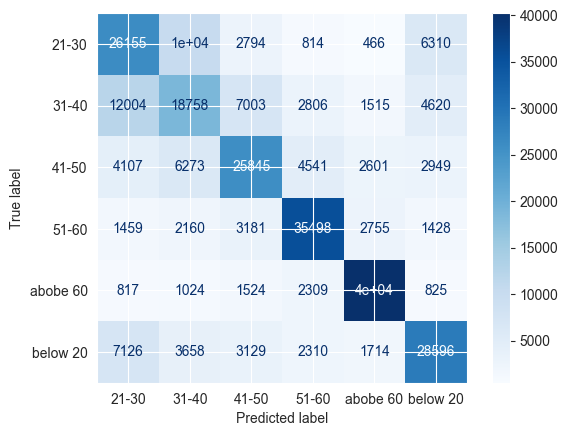

In [32]:
confusion_matrix = ConfusionMatrixDisplay.from_predictions(y_test,forest_pred,cmap='Blues')
print(confusion_matrix)

In [33]:
df.drop('vicservices',inplace=True,axis=1)

KeyError: "['vicservices'] not found in axis"

In [31]:
target_columns = df[['age','marital2']]

KeyError: "None of [Index(['age', 'marital2'], dtype='object')] are in the [columns]"

In [35]:
import pickle

pickle.dump(random_forest, open('age_pred.pkl','wb'))

In [36]:
from joblib import dump
dump(random_forest, 'age_pred_compressed.pkl', compress=3)

['age_pred_compressed.pkl']

In [1]:
df['Victim Age'].unique()

NameError: name 'df' is not defined

In [94]:
df4.head(10)

,City,State,Month,Crime Type,Victim Sex,Victim Age,Victim Race,Victim Ethnicity,Perpetrator Ethnicity,Weapon
0,35,1,4,1,1,14,2,2,2,0
1,35,1,7,1,1,43,4,2,2,13
2,35,1,7,1,0,30,2,2,2,15
3,35,1,0,1,1,43,4,2,2,13
4,35,1,0,1,0,30,2,2,2,15
5,35,1,8,1,1,30,4,2,2,11
6,35,1,8,1,0,42,2,2,2,9
7,35,1,6,1,0,99,4,2,2,9
8,35,1,6,1,1,32,4,2,2,6
9,35,1,6,1,1,38,4,2,2,6


In [61]:
df4['City'].min()

0

In [109]:
cc = df['Weapon'].unique()
dd = df4['Weapon'].unique()

In [110]:
# Pair the city name and its matching ID
paired = list(zip(cc, dd))  # [(City, ID), ...]

# Sort by city name (alphabetically)
paired_sorted = sorted(paired, key=lambda x: x[0])  # sort by city name (x[0])

# Generate the options
for city, id in paired_sorted:
    print(f'<option value="{id}">{city}</option>')

<option value="0">Blunt Object</option>
<option value="1">Drowning</option>
<option value="2">Drugs</option>
<option value="3">Explosives</option>
<option value="4">Fall</option>
<option value="5">Fire</option>
<option value="6">Firearm</option>
<option value="7">Gun</option>
<option value="8">Handgun</option>
<option value="9">Knife</option>
<option value="10">Poison</option>
<option value="11">Rifle</option>
<option value="12">Shotgun</option>
<option value="13">Strangulation</option>
<option value="14">Suffocation</option>
<option value="15">Unknown</option>


In [90]:
(df['Victim Age']=='Unknown').count()

565413